In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# configuração para exibir todas as colunas
pd.set_option('display.max_columns', None)



In [2]:
# definindo os caminhos dos arquivos processados (saída da Etapa 3)
caminho_atributos = '../dados/dados_processados/atributos_processados.csv'
caminho_rotulos = '../dados/dados_processados/rotulos_processados.csv'
caminho_codificador = '../modelos/codificador_rotulos.pkl'

# Carregando os dados
print(" Carregando dados processados...")
X = pd.read_csv(caminho_atributos)
y = pd.read_csv(caminho_rotulos)
codificador = joblib.load(caminho_codificador)

print(f"\n Dados carregados com sucesso!")
print(f" Formato dos atributos: {X.shape}")
print(f" Formato dos rótulos: {y.shape}")
print(f" Quantidade de tipos de registros: {len(codificador.classes_)}")


 Carregando dados processados...

 Dados carregados com sucesso!
 Formato dos atributos: (2520798, 78)
 Formato dos rótulos: (2520798, 1)
 Quantidade de tipos de registros: 15


In [3]:
# aqui será criado um 'novo' dataframe juntando os atributos e adicionando mais uma coluna que seriam os rotulos que ficarão na última coluna
# isso vai facilitar a manipulação dos dados mas vai ser apenas temporário

if isinstance(y, pd.DataFrame):
    y_serie = y.iloc[:, 0]
else:
    y_serie = y

df_completo = X.copy()
df_completo['Label'] = y_serie.values

print(f" DataFrame criado unindo os atributos e os rótulos")
print(f" Formato: {df_completo.shape}")
print(f" Colunas: {df_completo.shape[1]} (sendo {X.shape[1]} atributos + 1 rótulo no final)")
print(f"\n Primeiras linhas como exemplo:")
df_completo.head()


 DataFrame criado unindo os atributos e os rótulos
 Formato: (2520798, 79)
 Colunas: 79 (sendo 78 atributos + 1 rótulo no final)

 Primeiras linhas como exemplo:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,2.428596,-0.470914,-0.010425,-0.010950,-0.056662,-0.007566,-0.297774,-0.217169,-0.294064,-0.260452,-0.478315,-0.608911,-0.538480,-0.42738,0.097449,3.056580,-0.308793,-0.387637,-0.400986,-0.056537,-0.462141,-0.291448,-0.361725,-0.393648,-0.125357,-0.367533,-0.215868,-0.251675,-0.290615,-0.123461,-0.226182,0.0,-0.005634,0.0,0.001311,0.001660,3.238069,-0.170758,-0.423387,-0.498541,-0.580026,-0.499631,-0.314301,-0.182098,-0.226182,-0.016499,-0.650928,1.485409,-0.335907,-0.005634,-0.016535,-1.006882,-0.58881,-0.294064,-0.538480,0.001311,0.0,0.0,0.0,0.0,0.0,0.0,-0.010425,-0.056737,-0.010950,-0.007566,-0.495454,-0.249846,-0.007428,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
1,2.438537,-0.470911,-0.011684,-0.010003,-0.057228,-0.007563,-0.297774,-0.217169,-0.294064,-0.260452,-0.475372,-0.524261,-0.528994,-0.42738,-0.048949,-0.142833,-0.308771,-0.387637,-0.400982,-0.056501,-0.462141,-0.291448,-0.361725,-0.393648,-0.125357,-0.367533,-0.215868,-0.251675,-0.290615,-0.123461,-0.226182,0.0,-0.005634,0.0,0.001310,0.001673,-0.163947,0.069756,-0.423387,-0.498541,-0.580026,-0.499631,-0.314301,-0.182098,-0.226182,-0.016499,-0.650928,1.485409,2.977016,-0.005634,-0.016535,0.430602,-0.58881,-0.294064,-0.528994,0.001310,0.0,0.0,0.0,0.0,0.0,0.0,-0.011684,-0.057305,-0.010003,-0.007563,-0.495728,-0.221049,-0.008911,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
2,2.438590,-0.470913,-0.011684,-0.010003,-0.057228,-0.007563,-0.297774,-0.217169,-0.294064,-0.260452,-0.475372,-0.524261,-0.528994,-0.42738,-0.044407,-0.043577,-0.308783,-0.387637,-0.400985,-0.056520,-0.462141,-0.291448,-0.361725,-0.393648,-0.125357,-0.367533,-0.215868,-0.251675,-0.290615,-0.123461,-0.226182,0.0,-0.005634,0.0,0.001310,0.001673,-0.111913,0.333396,-0.423387,-0.498541,-0.580026,-0.499631,-0.314301,-0.182098,-0.226182,-0.016499,-0.650928,1.485409,2.977016,-0.005634,-0.016535,0.430602,-0.58881,-0.294064,-0.528994,0.001310,0.0,0.0,0.0,0.0,0.0,0.0,-0.011684,-0.057305,-0.010003,-0.007563,-0.495728,-0.221049,-0.008911,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
3,1.974744,-0.470913,-0.011684,-0.010003,-0.057228,-0.007563,-0.297774,-0.217169,-0.294064,-0.260452,-0.475372,-0.524261,-0.528994,-0.42738,-0.039809,0.056908,-0.308787,-0.387637,-0.400985,-0.056526,-0.462141,-0.291448,-0.361725,-0.393648,-0.125357,-0.367533,-0.215868,-0.251675,-0.290615,-0.123461,-0.226182,0.0,-0.005634,0.0,0.001310,0.001673,-0.059234,0.600301,-0.423387,-0.498541,-0.580026,-0.499631,-0.314301,-0.182098,-0.226182,-0.016499,-0.650928,1.485409,2.977016,-0.005634,-0.016535,0.430602,-0.58881,-0.294064,

In [4]:
# a partir daqui selecionaremos os 4 principais registros presentes no dataset para melhor manipulação para fins academicos
# é preciso descobrir qual número corresponde a cada classe que queremos manter
# o codificador que faz essa tradução 

# classes que vamos manter, 4 principais registros do dataset
classes_desejadas = ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']

# convertendo nomes em códigos numéricos, processo já feito em etapas passadas
codigos_desejados = codificador.transform(classes_desejadas)

print(" Classes selecionadas e seus códigos:")
print("=" * 50)
for nome, codigo in zip(classes_desejadas, codigos_desejados):
    print(f"   {nome:15s} → código {codigo}")
print("=" * 50)



 Classes selecionadas e seus códigos:
   BENIGN          → código 0
   DDoS            → código 2
   DoS Hulk        → código 4
   PortScan        → código 10


In [5]:
# agora vamos ajustar o dataframe para manter apenas os registros das 4 classes
df_filtrado = df_completo[df_completo['Label'].isin(codigos_desejados)].copy()

print(f" Total antes da seleção das 4 classes:  {len(df_completo):,} registros")
print(f" Total depois da seleção: {len(df_filtrado):,} registros")
print(f" Registros descartados:     {len(df_completo) - len(df_filtrado):,}")

print(f"\n Distribuição das 4 classes selecionadas:")
distribuicao = df_filtrado['Label'].value_counts().sort_index()
for codigo, quantidade in distribuicao.items():
    nome = codificador.inverse_transform([codigo])[0]
    print(f"   {nome:15s} (código {codigo}): {quantidade:,} registros")


 Total antes da seleção das 4 classes:  2,520,798 registros
 Total depois da seleção: 2,486,611 registros
 Registros descartados:     34,187

 Distribuição das 4 classes selecionadas:
   BENIGN          (código 0): 2,095,057 registros
   DDoS            (código 2): 128,014 registros
   DoS Hulk        (código 4): 172,846 registros
   PortScan        (código 10): 90,694 registros


In [6]:
# processo de escolha dos registros: será feita de forma aleatória para evitar viés Realizando a amostragem aleatória de 2500 registros por classe
# vamos diminuir o dataset para 10000 registros, sendo 2500 de cada uma das quatro classes
# usando random_state=1 para ter uma semente (seed) sempre igual em todo projeto

REGISTROS_POR_CLASSE = 2500
SEMENTE = 1

print(f" Semente (seed): {SEMENTE}")
print(f" Registros por classe: {REGISTROS_POR_CLASSE}")
print()

# lista para armazenar os registros de cada classe
amostras = []

for codigo in codigos_desejados:
    # filtra registros da classe atual
    df_classe = df_filtrado[df_filtrado['Label'] == codigo]
    
    # sorteia 2500 registros aleatoriamente
    df_amostra = df_classe.sample(n=REGISTROS_POR_CLASSE, random_state=SEMENTE)
    
    # adiciona na lista
    amostras.append(df_amostra)
    
    # log
    nome = codificador.inverse_transform([codigo])[0]
    print(f"  {nome:15s}: {len(df_classe):,} disponíveis → {len(df_amostra):,} sorteados")

# concatenando todas as amostras em um único dataframe para ser usado daqui pra frente
df_amostrado = pd.concat(amostras, ignore_index=True)

print(f"\n Total de registros selecionados: {len(df_amostrado):,}")


 Semente (seed): 1
 Registros por classe: 2500

  BENIGN         : 2,095,057 disponíveis → 2,500 sorteados
  DDoS           : 128,014 disponíveis → 2,500 sorteados
  DoS Hulk       : 172,846 disponíveis → 2,500 sorteados
  PortScan       : 90,694 disponíveis → 2,500 sorteados

 Total de registros selecionados: 10,000


In [7]:
# vamos deixar as linhas embaralhadas para que os registros não fiquem agrupados por classe, como se fosse uma sequência
# mais uma vez, isso serve para não gerar viés

df_amostrado = df_amostrado.sample(frac=1, random_state=SEMENTE).reset_index(drop=True)

print(" DataFrame embaralhado")
print(f" Total de registros: {len(df_amostrado):,}")
print(f"\n Primeiras 10 linhas (apenas como exemplo para verificar o embaralhamento):")
df_amostrado[['Label']].head(10)


 DataFrame embaralhado
 Total de registros: 10,000

 Primeiras 10 linhas (apenas como exemplo para verificar o embaralhamento):


,Label
0,10
1,2
2,2
3,2
4,4
5,10
6,0
7,0
8,0
9,10


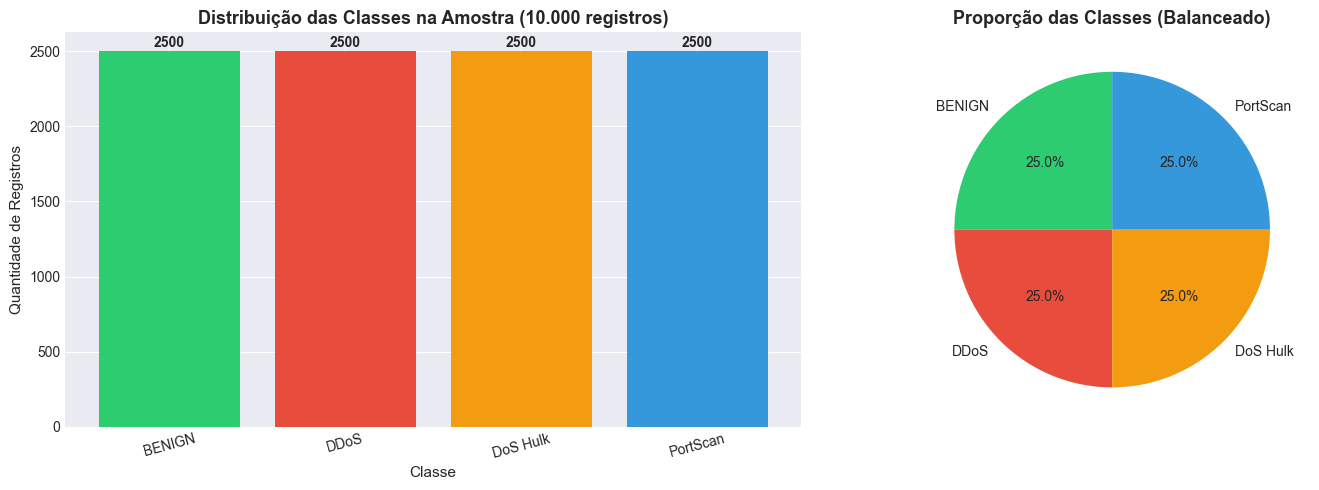


 Resumo da distribuição final:
   BENIGN         : 2,500 registros (25.0%)
   DDoS           : 2,500 registros (25.0%)
   DoS Hulk       : 2,500 registros (25.0%)
   PortScan       : 2,500 registros (25.0%)
   TOTAL          : 10,000 registros (100.0%)


In [9]:
# verificando a distribuição final das classes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# gráfico de barras gerado para mostrar a distribuição 
distribuicao_final = df_amostrado['Label'].value_counts().sort_index()
nomes_classes = [codificador.inverse_transform([c])[0] for c in distribuicao_final.index]

axes[0].bar(nomes_classes, distribuicao_final.values, color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
axes[0].set_title('Distribuição das Classes na Amostra (10.000 registros)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe', fontsize=11)
axes[0].set_ylabel('Quantidade de Registros', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(distribuicao_final.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# gráfico de pizza gerado para mostrar a distribuição 
axes[1].pie(distribuicao_final.values, labels=nomes_classes, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'], startangle=90)
axes[1].set_title('Proporção das Classes (Balanceado)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Resumo da distribuição final:")
print("=" * 50)
for nome, qtd in zip(nomes_classes, distribuicao_final.values):
    pct = (qtd / len(df_amostrado)) * 100
    print(f"   {nome:15s}: {qtd:,} registros ({pct:.1f}%)")
print("=" * 50)
print(f"   {'TOTAL':15s}: {len(df_amostrado):,} registros (100.0%)")


In [10]:
# separando o dataframe em atributos (X) e rótulos (y), que anteriormente havia sido unificado
X_amostrado = df_amostrado.drop(columns=['Label'])
y_amostrado = df_amostrado['Label']

print(f" X da amostra (atributos): {X_amostrado.shape}")
print(f" y da amostra (rótulos):   {y_amostrado.shape}")
print(f"\n Primeiras linhas dos atributos para confirmar:")
X_amostrado.head()


 X da amostra (atributos): (10000, 78)
 y da amostra (rótulos):   (10000,)

 Primeiras linhas dos atributos para confirmar:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0.068765,-0.470913,-0.011684,-0.010003,-0.057795,-0.007563,-0.305707,-0.315856,-0.324746,-0.260452,-0.475372,-0.524261,-0.528994,-0.427380,-0.048832,-0.047158,-0.308783,-0.387637,-0.400984,-0.056520,-0.462141,-0.291448,-0.361725,-0.393648,-0.125357,-0.367533,-0.215868,-0.251675,-0.290615,-0.123461,-0.226182,0.0,-0.005634,0.0,0.001311,0.001673,-0.113790,0.323884,-0.657907,-0.498541,-0.592590,-0.494390,-0.314294,-0.182098,-0.226182,-0.016499,1.536268,-0.673215,-0.335907,-0.005634,-0.016535,0.430602,-0.606176,-0.324746,-0.528994,0.001311,0.0,0.0,0.0,0.0,0.0,0.0,-0.011684,-0.057872,-0.010003,-0.007563,1.502567,-0.249734,-0.008911,0.002716,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764
1,-0.452884,-0.385001,-0.006649,-0.010950,-0.054962,-0.007566,-0.297774,-0.217169,-0.294064,-0.260452,-0.478315,-0.608911,-0.538480,-0.427380,-0.053092,-0.233375,-0.147208,-0.208819,-0.283212,-0.056537,-0.376066,-0.215898,-0.212621,-0.276245,-0.125357,-0.367533,-0.215868,-0.251675,-0.290615,-0.123461,-0.226182,0.0,-0.005634,0.0,0.001313,0.001660,-0.211409,-0.170758,-0.423387,-0.498541,-0.580026,-0.499631,-0.314301,-0.182098,-0.226182,-0.016499,-0.650928,1.485409,-0.335907,-0.005634,-0.016535,-1.006882,-0.594020,-0.294064,-0.538480,0.001313,0.0,0.0,0.0,0.0,0.0,0.0,-0.006649,-0.055035,-0.010950,-0.007566,-0.480178,-0.249846,-0.002980,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764
2,-0.452884,-0.433701,-0.009166,-0.007165,-0.055339,-0.002728,-0.279265,-0.315856,-0.280427,-0.225882,3.061318,-0.608911,4.046436,3.590535,-0.052759,-0.233356,-0.262133,-0.325569,-0.350770,-0.056537,-0.461544,-0.290399,-0.360260,-0.392833,-0.125357,-0.324164,-0.169346,-0.140270,-0.219360,-0.123442,-0.226182,0.0,-0.005634,0.0,0.001312,0.001720,-0.211406,-0.170679,-0.657907,2.899219,3.966377,3.716298,4.156383,-0.182098,-0.226182,-0.016499,1.536268,-0.673215,-0.335907,-0.005634,-0.016535,0.430602,4.192623,-0.280427,4.046436,0.001312,0.0,0.0,0.0,0.0,0.0,0.0,-0.009166,-0.055413,-0.007165,-0.002728,0.063460,-0.224074,-0.005945,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764
3,-0.452884,-0.437288,-0.009166,-0.004327,-0.055339,-0.002728,-0.279265,-0.315856,-0.280427,-0.225882,2.386752,-0.608911,2.081472,1.802783,-0.052723,-0.233341,-0.280685,-0.341289,-0.355169,-0.056533,-0.461932,-0.291081,-0.361221,-0.393365,-0.125350,-0.328344,-0.194849,-0.179309,-0.225603,-0.123459,-0.226182,0.0,-0.005634,0.0,0.001312,0.001759,-0.211404,-0.170604,-0.657907,2.251151,2.721309,2.125600,1.419194,-0.182098,-0.226182,-0.016499,1.536268,-0.673215,-0.335907,-0.005634,-0.016535,1.868086,2.750378,-0.280427,2.081472,0.

In [11]:
# como agora só temos apenas 4 classes, vamos atualizar o codificador para ficar mais fácil
# os códigos atuais de cada classes vão ser remapeados para 0, 1, 2, 3

from sklearn.preprocessing import LabelEncoder

# recuperando os nomes das classes que estão na amostra
nomes_originais = codificador.inverse_transform(y_amostrado.values)

# criando um novo codificador só com as 4 classes
novo_codificador = LabelEncoder()
y_amostrado_recodificado = novo_codificador.fit_transform(nomes_originais)

y_amostrado_final = pd.Series(y_amostrado_recodificado, name='Label')

print(" Codificador atualizado")
print("\n Novo mapeamento das classes:")
print("=" * 50)
for codigo, nome in enumerate(novo_codificador.classes_):
    qtd = (y_amostrado_final == codigo).sum()
    print(f"   {nome:15s} → código {codigo} ({qtd:,} registros)")
print("=" * 50)


 Codificador atualizado

 Novo mapeamento das classes:
   BENIGN          → código 0 (2,500 registros)
   DDoS            → código 1 (2,500 registros)
   DoS Hulk        → código 2 (2,500 registros)
   PortScan        → código 3 (2,500 registros)


In [12]:
# definindo os caminhos de saída
pasta_dados = '../dados/dados_processados/'
pasta_modelos = '../modelos/'

caminho_X_amostrado = os.path.join(pasta_dados, 'atributos_amostrados.csv')
caminho_y_amostrado = os.path.join(pasta_dados, 'rotulos_amostrados.csv')
caminho_novo_codificador = os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl')

# salvando os arquivos
print(" Salvando arquivos...")

X_amostrado.to_csv(caminho_X_amostrado, index=False)
print(f" Atributos salvos: {caminho_X_amostrado}")

y_amostrado_final.to_csv(caminho_y_amostrado, index=False)
print(f" Rótulos salvos:   {caminho_y_amostrado}")

joblib.dump(novo_codificador, caminho_novo_codificador)
print(f" Codificador salvo: {caminho_novo_codificador}")

print(f"\n Resumo da etapa: ")
print(f" Dataset reduzido de +2.5M de registros para {len(X_amostrado):,} registros")
print(f" Classes reduzidas de 15 para {len(novo_codificador.classes_)}")


 Salvando arquivos...
 Atributos salvos: ../dados/dados_processados/atributos_amostrados.csv
 Rótulos salvos:   ../dados/dados_processados/rotulos_amostrados.csv
 Codificador salvo: ../modelos/codificador_rotulos_amostrado.pkl

 Resumo da etapa: 
 Dataset reduzido de +2.5M de registros para 10,000 registros
 Classes reduzidas de 15 para 4
